In [1]:
from moabb.datasets import *
from moabb.paradigms import P300
import tensorly as tl

dataset = BNCI2014_008()
paradigm = P300(resample=32)
X, y, meta = paradigm.get_data(dataset, subjects=[1])
X = tl.tensor(X)
X.shape

/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:278: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MiB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


(4200, 8, 32)

In [2]:
from bttda.hoda import BTTDA

bttda = BTTDA(
    ranks=[None]*8,
    hoda_params=dict(
        rank=None,
        shrinkage='lw',
        obj='tr',
        verbose=True,
        theta=0.2,
        toeplitz=(1,),       
    ),
    verbose=True,
    extra_train_info=True,

)
bttda.fit(X,y)

Fitting block 1/8...


Forward model :  16%|█▋        | 42/255 [00:00<00:00, 317.53it/s]


Fitting block 2/8...


Forward model :   4%|▎         | 9/255 [00:00<00:00, 309.75it/s]


Fitting block 3/8...


...

Fitting block 7/8...


Forward model :   4%|▍         | 10/255 [00:00<00:00, 302.99it/s]


Fitting block 8/8...


Forward model :   7%|▋         | 18/255 [00:00<00:00, 301.49it/s]


BTTDA(extra_train_info=True,
      hoda_params={'obj': 'tr', 'rank': None, 'shrinkage': 'lw', 'theta': 0.2,
                   'toeplitz': (1,), 'verbose': True},
      ranks=[None, None, None, None, None, None, None, None], verbose=True)

In [3]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,mse,nmse
0,1,"(1, 4)",0.216033,0.000171,78.965739,0.997200
1,2,"(1, 4)",0.201634,0.000174,78.687874,0.993691
2,3,"(1, 4)",0.169493,0.000179,78.199350,0.987522
3,4,"(1, 4)",0.148433,0.000219,77.871165,0.983377
4,5,"(1, 4)",0.123873,0.000234,77.333670,0.976590
5,6,"(1, 4)",0.116507,0.000235,77.112955,0.973802
6,7,"(1, 4)",0.109115,0.000239,76.965135,0.971936
7,8,"(1, 4)",0.102600,0.000241,76.828659,0.970212


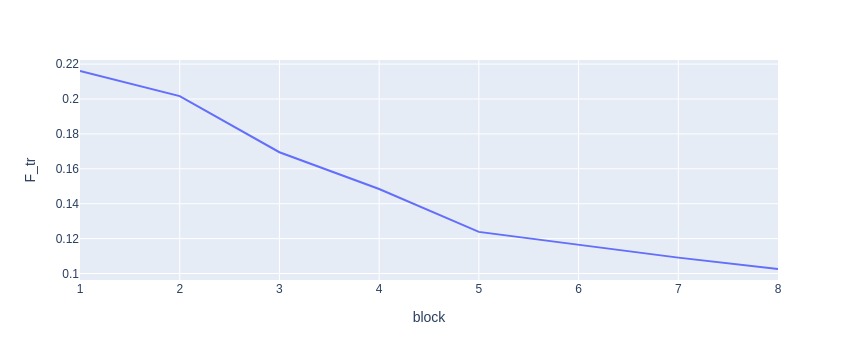

In [4]:
import plotly.express as px

if bttda.extra_train_info:
    fig = px.line(df, x='block', y='F_tr')
    fig.show()


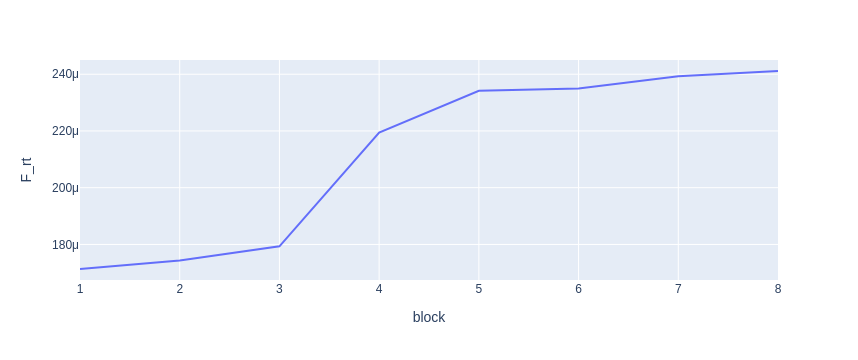

In [5]:
if bttda.extra_train_info:
    fig = px.line(df, x='block', y='F_rt')
    fig.show()


In [6]:
if bttda.extra_train_info:
    fig = px.line(df, x='block', y='nmse')
    fig.show()


In [7]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from bttda.classification import SelectFCutoff

Xt = bttda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))

select = SelectFCutoff()
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'significant': select.scores_>1,
})
df

,feature,F,significant
0,0,1.168395,True
1,1,69.796128,True
2,2,0.021906,False
3,3,795.200298,True
4,4,2.614842,True
5,5,50.809137,True
6,6,0.015946,False
7,7,756.471674,True
8,8,0.026258,False
9,9,5.536013,True


In [8]:
fig = px.bar(df, x='feature', y='F', color='significant', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

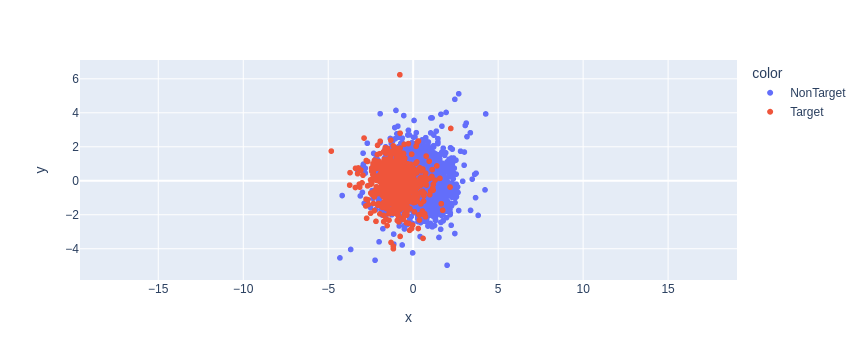

In [9]:
from sklearn.decomposition import PCA

x_viz = PCA(n_components=2, whiten=True).fit_transform(xts)
fig = px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)
fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
  )

In [10]:
from bttda.hoda import f_multiway

print(f"trace-ratio: {f_multiway(xts,y, method='tr')}")
print(f"ratio-trace: {f_multiway(xts,y, method='rt')}")

trace-ratio: 0.13698997885155137
ratio-trace: 0.00023716684326132397
